In [ ]:
%cd /content
!git clone https://github.com/RenYurui/PIRender.git
%cd /content/PIRender

!pip install -q gdown lmdb scipy pyyaml imageio scikit-image opencv-python-headless

/content
Cloning into 'PIRender'...
remote: Enumerating objects: 147, done.
remote: Counting objects: 100% (147/147), done.
remote: Compressing objects: 100% (116/116), done.
remote: Total 147 (delta 41), reused 126 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (147/147), 197.67 KiB | 941.00 KiB/s, done.
Resolving deltas: 100% (41/41), done.
/content/PIRender
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.9/325.9 kB 20.0 MB/s eta 0:00:00


In [ ]:
%cd /content/PIRender
!bash ./scripts/download_weights.sh
!find /content/PIRender/result -maxdepth 3 | head -50

/content/PIRender
Downloading...
From (original): https://drive.google.com/uc?id=1-0xOf6g58OmtKtEWJlU3VlnfRqPN9Uq7
From (redirected): https://drive.google.com/uc?id=1-0xOf6g58OmtKtEWJlU3VlnfRqPN9Uq7&confirm=t&uuid=fde12fd8-bd9d-4567-9b0f-1ddeec185c4b
To: /content/PIRender/face.zip
100% 167M/167M [00:13<00:00, 12.5MB/s]
Archive:  ./face.zip
   creating: face/
  inflating: face/epoch_00190_iteration_000400000_checkpoint.pt  
  inflating: face/latest_checkpoint.txt  
/content/PIRender/result
/content/PIRender/result/face
/content/PIRender/result/face/epoch_00190_iteration_000400000_checkpoint.pt
/content/PIRender/result/face/latest_checkpoint.txt


In [ ]:
import os, shutil, numpy as np

INPUT_DIR = "/content/PIRender/custom_input"
os.makedirs(INPUT_DIR, exist_ok=True)

SRC_IMG = "/content/source.jpeg"
assert os.path.exists(SRC_IMG), "source.jpg 업로드해줘"

shutil.copy(SRC_IMG, f"{INPUT_DIR}/frame_00000.jpg")
print("saved:", f"{INPUT_DIR}/frame_00000.jpg")

saved: /content/PIRender/custom_input/frame_00000.jpg


In [ ]:
import numpy as np
import os

# 예: 네 meta.txt
META_PATH = "/content/meta.txt"   # 없으면 /content/meta.txt 등으로 바꿔
coeff_q = np.loadtxt(META_PATH).astype(np.float32).reshape(-1)
assert len(coeff_q) == 265, f"need 265 coeff, got {len(coeff_q)}"

# Qualcomm raw 분해
alpha_id  = coeff_q[0:219]
alpha_exp = coeff_q[219:258]
pitch     = coeff_q[258]
yaw       = coeff_q[259]
roll      = coeff_q[260]
tx        = coeff_q[261]
ty        = coeff_q[262]
f         = coeff_q[263]

# PIRender용 262 coeff 가짜 패키지 생성
# 핵심은 expression/pose/trans만 넣는 것
pir_coeff = np.zeros(262, dtype=np.float32)

# exp 64칸
# Qualcomm exp는 39차원이라 앞쪽 39개만 채우고 나머지는 0
pir_coeff[80:80+39] = alpha_exp[:39]

# angle 3칸
pir_coeff[224:227] = np.array([yaw, pitch, roll], dtype=np.float32)

# translation 3칸
pir_coeff[254:257] = np.array([tx, ty, 0.0], dtype=np.float32)

# crop 3칸
pir_coeff[259:262] = np.array([0.0, 0.0, f], dtype=np.float32)

np.savetxt(f"{INPUT_DIR}/frame_00000_3dmm_coeff.txt", pir_coeff[None], fmt="%.8f")
print("saved:", f"{INPUT_DIR}/frame_00000_3dmm_coeff.txt")
print("coeff len:", len(pir_coeff))

saved: /content/PIRender/custom_input/frame_00000_3dmm_coeff.txt
coeff len: 262


In [ ]:
%%writefile /content/PIRender/run_custom_inference.py
import os
import torch
from config import Config
from util.logging import init_logging, make_logging_dir
from util.trainer import get_model_optimizer_and_scheduler, get_trainer, set_random_seed
from data.image_dataset import ImageDataset
from inference import write2video

class Args:
    config = "./config/face_demo.yaml"
    name = "face"
    checkpoints_dir = "result"
    seed = 0
    which_iter = None
    no_resume = True
    output_dir = "./custom_result"
    single_gpu = True
    local_rank = 0

args = Args()

set_random_seed(args.seed)
opt = Config(args.config, args, is_train=False)

# 최신 코랩용 강제 설정
opt.distributed = False
opt.local_rank = 0
opt.single_gpu = True
opt.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

date_uid, logdir = init_logging(opt)
opt.logdir = logdir
make_logging_dir(logdir, date_uid)

net_G, net_G_ema, opt_G, sch_G = get_model_optimizer_and_scheduler(opt)
trainer = get_trainer(opt, net_G, net_G_ema, opt_G, sch_G, None)
current_epoch, current_iteration = trainer.load_checkpoint(opt, args.which_iter)
net_G = trainer.net_G_ema.eval()

input_dir = "/content/PIRender/custom_input"
output_dir = os.path.join(args.output_dir, f"epoch_{current_epoch:05}_iteration_{current_iteration:09}")
os.makedirs(output_dir, exist_ok=True)

dataset = ImageDataset(opt.data, input_dir)
print("dataset len =", len(dataset))

output_images = []
with torch.no_grad():
    for _ in range(len(dataset)):
        data = dataset.next_image()
        source = data["source_image"].to(opt.device)
        target = data["target_semantics"].to(opt.device)
        out = net_G(source, target)
        output_images.append(out["fake_image"].cpu().clamp_(-1, 1))

video = torch.cat(output_images, 0)
write2video(os.path.join(output_dir, "custom_drive"), video)
print("saved:", os.path.join(output_dir, "custom_drive.mp4"))

Writing /content/PIRender/run_custom_inference.py


In [ ]:
from pathlib import Path

# torch._six 패치
p = Path("/content/PIRender/util/misc.py")
text = p.read_text(encoding="utf-8")
text = text.replace(
    "from torch._six import container_abcs, string_classes",
    "import collections.abc as container_abcs\nstring_classes = (str, bytes)"
)
p.write_text(text, encoding="utf-8")

# compare_ssim 패치
p2 = Path("/content/PIRender/third_part/PerceptualSimilarity/util/util.py")
text2 = p2.read_text(encoding="utf-8")
text2 = text2.replace(
    "from skimage.measure import compare_ssim",
    "from skimage.metrics import structural_similarity as compare_ssim"
)
p2.write_text(text2, encoding="utf-8")

print("patched")

patched


In [ ]:
%cd /content/PIRender
!python run_custom_inference.py

/content/PIRender
2026-03-26 06:43:46.004484: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-26 06:43:46.008956: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-26 06:43:46.022614: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774507426.048082    3545 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774507426.055533    3545 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774507426.074207    3545 computation_placer.cc:177] computation placer already registered. Please check linkag

In [ ]:
!find /content/PIRender/custom_result -name "*.mp4"

find: ‘/content/PIRender/custom_result’: No such file or directory


In [ ]:
from IPython.display import Video
Video('/content/PIRender/custom_result/epoch_00020_iteration_000040000/custom_drive.mp4', embed=True)

여기부터 다른거


In [ ]:
%cd /content
!git clone https://github.com/RenYurui/PIRender.git
%cd /content/PIRender
!pip install -q gdown lmdb scipy pyyaml imageio scikit-image opencv-python-headless

/content
Cloning into 'PIRender'...
remote: Enumerating objects: 147, done.
remote: Counting objects: 100% (147/147), done.
remote: Compressing objects: 100% (116/116), done.
remote: Total 147 (delta 41), reused 126 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (147/147), 197.67 KiB | 9.41 MiB/s, done.
Resolving deltas: 100% (41/41), done.
/content/PIRender
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.9/325.9 kB 12.3 MB/s eta 0:00:00


In [ ]:
!bash ./scripts/download_weights.sh
!find /content/PIRender/result -maxdepth 3 | head -50

Downloading...
From (original): https://drive.google.com/uc?id=1-0xOf6g58OmtKtEWJlU3VlnfRqPN9Uq7
From (redirected): https://drive.google.com/uc?id=1-0xOf6g58OmtKtEWJlU3VlnfRqPN9Uq7&confirm=t&uuid=eca064cf-83c5-4c22-8805-b82a4724f4f5
To: /content/PIRender/face.zip
100% 167M/167M [00:00<00:00, 215MB/s]
Archive:  ./face.zip
   creating: face/
  inflating: face/epoch_00190_iteration_000400000_checkpoint.pt  
  inflating: face/latest_checkpoint.txt  
/content/PIRender/result
/content/PIRender/result/face
/content/PIRender/result/face/epoch_00190_iteration_000400000_checkpoint.pt
/content/PIRender/result/face/latest_checkpoint.txt


In [ ]:
import os, shutil, numpy as np

SRC_IMG = "/content/source.jpeg"
META_PATH = "/content/meta.txt" if os.path.exists("/mnt/data/meta.txt") else "/content/meta.txt"

print("source exists:", os.path.exists(SRC_IMG))
print("meta exists:", os.path.exists(META_PATH))

source exists: True
meta exists: True


In [ ]:
import numpy as np
import os, shutil

# coeff_q = np.loadtxt(META_PATH).astype(np.float32).reshape(-1)
# assert len(coeff_q) == 265, f"expected 265 coeff, got {len(coeff_q)}"
coeff_q = np.loadtxt(META_PATH, delimiter=",").astype(np.float32).reshape(-1)
assert len(coeff_q) == 265, f"expected 265 coeff, got {len(coeff_q)}"

print("len:", len(coeff_q))
print(coeff_q[:10])

# Qualcomm coeff 분해
alpha_id  = coeff_q[0:219]
alpha_exp = coeff_q[219:258]   # 39
pitch     = coeff_q[258]
yaw       = coeff_q[259]
roll      = coeff_q[260]
tx        = coeff_q[261]
ty        = coeff_q[262]
f         = coeff_q[263]
extra     = coeff_q[264]

# # PIRender용 coeff 생성
# pir_coeff = np.zeros(262, dtype=np.float32)

# # expression 64칸 중 앞 39칸만 채움
# pir_coeff[80:80+39] = alpha_exp

# # pose
# pir_coeff[224:227] = np.array([yaw, pitch, roll], dtype=np.float32)

# # translation
# pir_coeff[254:257] = np.array([tx, ty, 0.0], dtype=np.float32)

# # crop
# # f를 crop 자리에 그대로 넣는 건 과할 수 있어서 일단 0으로 시작
# pir_coeff[259:262] = np.array([0.0, 0.0, 0.0], dtype=np.float32)
pir_coeff = np.zeros(262, dtype=np.float32)

# 🔥 expression 줄여서 넣기
exp_scaled = alpha_exp * 1.1
pir_coeff[80:80+39] = exp_scaled

# 🔥 pose도 줄이기
pir_coeff[224:227] = np.array([
    yaw * 1.1,
    pitch * 1.1,
    roll * 1.1
], dtype=np.float32)

# 🔥 translation 거의 제거
pir_coeff[254:257] = np.array([0.0, 0.0, 0.0], dtype=np.float32)

# 🔥 crop 절대 건들지마
pir_coeff[259:262] = np.array([0.0, 0.0, 0.0], dtype=np.float32)

INPUT_DIR = "/content/PIRender/custom_input"
os.makedirs(INPUT_DIR, exist_ok=True)

shutil.copy(SRC_IMG, f"{INPUT_DIR}/frame_00000.jpg")
np.savetxt(f"{INPUT_DIR}/frame_00000_3dmm_coeff.txt", pir_coeff[None], fmt="%.8f")

print("saved image:", f"{INPUT_DIR}/frame_00000.jpg")
print("saved coeff:", f"{INPUT_DIR}/frame_00000_3dmm_coeff.txt")
print("coeff len:", len(pir_coeff))
print("exp part:", pir_coeff[80:144][:45])
print("pose:", pir_coeff[224:227])
print("trans:", pir_coeff[254:257])
print("crop:", pir_coeff[259:262])

len: 265
[-0.730656   -0.5058388   0.05620431  0.16861293  0.          0.
  0.22481725 -0.05620431  0.         -0.05620431]
saved image: /content/PIRender/custom_input/frame_00000.jpg
saved coeff: /content/PIRender/custom_input/frame_00000_3dmm_coeff.txt
coeff len: 262
exp part: [-1.1128454  -0.9891959  -0.8655464  -0.74189687 -1.1128454  -1.1128454
 -0.92737114 -1.2983197  -1.1128454  -1.1128454  -1.1128454  -1.0510206
 -1.1128454  -0.80372167 -1.4219692  -1.1128454  -1.1128454  -1.1128454
 -1.1128454  -1.1746702  -0.74189687 -0.92737114 -0.8655464  -1.1128454
 -1.2364949  -1.4837937  -1.0510206  -1.1128454  -1.1746702  -1.4837937
 -0.9891959  -1.3601444  -1.3601444  -0.80372167 -1.1128454  -1.1128454
 -1.4837937  -0.9891959  -0.92737114  0.          0.          0.
  0.          0.          0.        ]
pose: [-0.24729897 -0.12364949  0.06182474]
trans: [0. 0. 0.]
crop: [0. 0. 0.]


In [ ]:
from pathlib import Path

# torch._six 패치
p = Path("/content/PIRender/util/misc.py")
text = p.read_text(encoding="utf-8")
text = text.replace(
    "from torch._six import container_abcs, string_classes",
    "import collections.abc as container_abcs\nstring_classes = (str, bytes)"
)
p.write_text(text, encoding="utf-8")

# compare_ssim 패치
p2 = Path("/content/PIRender/third_part/PerceptualSimilarity/util/util.py")
text2 = p2.read_text(encoding="utf-8")
text2 = text2.replace(
    "from skimage.measure import compare_ssim",
    "from skimage.metrics import structural_similarity as compare_ssim"
)
p2.write_text(text2, encoding="utf-8")

print("patched")

patched


In [ ]:
# %%writefile /content/PIRender/run_image_inference.py
# import os
# import torch
# import torchvision.utils as vutils
# from config import Config
# from util.trainer import get_model_optimizer_and_scheduler, get_trainer, set_random_seed
# from data.image_dataset import ImageDataset

# class Args:
#     config = "./config/face_demo.yaml"
#     name = "face"
#     checkpoints_dir = "result"
#     seed = 0
#     which_iter = None
#     no_resume = True
#     output_dir = "./custom_result"
#     single_gpu = True
#     local_rank = 0

# args = Args()

# set_random_seed(args.seed)
# opt = Config(args.config, args, is_train=False)
# opt.distributed = False
# opt.local_rank = 0
# opt.single_gpu = True
# opt.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# net_G, net_G_ema, opt_G, sch_G = get_model_optimizer_and_scheduler(opt)
# trainer = get_trainer(opt, net_G, net_G_ema, opt_G, sch_G, None)
# current_epoch, current_iteration = trainer.load_checkpoint(opt, args.which_iter)
# net_G = trainer.net_G_ema.eval()

# dataset = ImageDataset(opt.data, "/content/PIRender/custom_input")
# data = dataset.next_image()

# source = data["source_image"].to(opt.device)
# target = data["target_semantics"].to(opt.device)

# with torch.no_grad():
#     out = net_G(source, target)

# img = out["fake_image"].cpu()
# os.makedirs(args.output_dir, exist_ok=True)
# out_path = os.path.join(args.output_dir, "result.png")
# vutils.save_image((img + 1) / 2, out_path)

# print("saved:", out_path)

In [ ]:
%%writefile /content/PIRender/run_image_inference.py
import os
import torch
import torchvision.utils as vutils
from config import Config
from util.logging import init_logging, make_logging_dir
from util.trainer import get_model_optimizer_and_scheduler, get_trainer, set_random_seed
from data.image_dataset import ImageDataset

class Args:
    config = "./config/face_demo.yaml"
    name = "face"
    checkpoints_dir = "result"
    seed = 0
    which_iter = None
    no_resume = True
    output_dir = "./custom_result"
    single_gpu = True
    local_rank = 0

args = Args()

set_random_seed(args.seed)
opt = Config(args.config, args, is_train=False)

# 코랩/CPU 대응
opt.distributed = False
opt.local_rank = 0
opt.single_gpu = True
opt.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 🔥 이 부분 추가
date_uid, logdir = init_logging(opt)
opt.logdir = logdir
make_logging_dir(logdir, date_uid)

net_G, net_G_ema, opt_G, sch_G = get_model_optimizer_and_scheduler(opt)
trainer = get_trainer(opt, net_G, net_G_ema, opt_G, sch_G, None)

current_epoch, current_iteration = trainer.load_checkpoint(opt, args.which_iter)
net_G = trainer.net_G_ema.eval()

dataset = ImageDataset(opt.data, "/content/PIRender/custom_input")
print("dataset len =", len(dataset))

data = dataset.next_image()
source = data["source_image"].to(opt.device)
target = data["target_semantics"].to(opt.device)

with torch.no_grad():
    out = net_G(source, target)

img = out["fake_image"].cpu()
print("output tensor shape:", img.shape)
print("min/max:", img.min().item(), img.max().item())

os.makedirs(args.output_dir, exist_ok=True)
out_path = os.path.join(args.output_dir, "result.png")
vutils.save_image((img + 1) / 2, out_path)

print("saved:", out_path)

Overwriting /content/PIRender/run_image_inference.py


In [ ]:
%cd /content/PIRender
!python run_image_inference.py

/content/PIRender
2026-03-26 07:06:30.387893: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774508790.408049    4244 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774508790.414748    4244 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774508790.431745    4244 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774508790.431773    4244 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774508790.431777    4244 computation_placer.cc:177] comp

In [ ]:
!find /content/PIRender -name "*.png"

/content/PIRender/custom_result/result.png


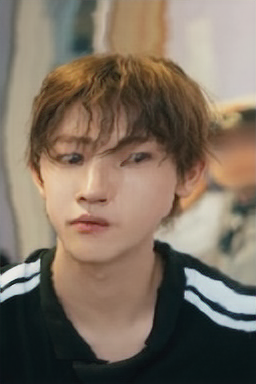

In [ ]:
from IPython.display import Image, display
display(Image(filename="/content/PIRender/custom_result/result.png"))

mediapipe


In [ ]:
%cd /content
!git clone https://github.com/RenYurui/PIRender.git
%cd /content/PIRender

/content
fatal: destination path 'PIRender' already exists and is not an empty directory.
/content/PIRender


In [ ]:
!pip -q install mediapipe opencv-python-headless matplotlib

In [ ]:
!bash ./scripts/download_weights.sh
!find /content/PIRender/result -maxdepth 3 | head -50

Downloading...
From (original): https://drive.google.com/uc?id=1-0xOf6g58OmtKtEWJlU3VlnfRqPN9Uq7
From (redirected): https://drive.google.com/uc?id=1-0xOf6g58OmtKtEWJlU3VlnfRqPN9Uq7&confirm=t&uuid=5efce862-f8cd-46fc-8416-dd702d8f2a56
To: /content/PIRender/face.zip
100% 167M/167M [00:00<00:00, 275MB/s]
Archive:  ./face.zip
   creating: face/
  inflating: face/epoch_00190_iteration_000400000_checkpoint.pt  
  inflating: face/latest_checkpoint.txt  
mkdir: cannot create directory ‘./result’: File exists
mv: cannot move 'face' to './result/face': Directory not empty
/content/PIRender/result
/content/PIRender/result/face
/content/PIRender/result/face/image
/content/PIRender/result/face/evaluation
/content/PIRender/result/face/loss_log.txt
/content/PIRender/result/face/epoch_00190_iteration_000400000_checkpoint.pt
/content/PIRender/result/face/latest_checkpoint.txt
/content/PIRender/result/face/tensorboard
/content/PIRender/result/face/tensorboard/events.out.tfevents.1774508570.1d6a9385e8f2.3

In [ ]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

In [ ]:
import os

MODEL_PATH = "/content/face_landmarker.task"
SRC_IMG = "/content/source.jpeg"
DRV_IMG = "/content/driving.png"

print("model:", os.path.exists(MODEL_PATH))
print("source:", os.path.exists(SRC_IMG))
print("driving:", os.path.exists(DRV_IMG))

model: True
source: True
driving: True


In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt

BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.IMAGE,
    num_faces=1,
    min_face_detection_confidence=0.5,
    min_face_presence_confidence=0.5,
    min_tracking_confidence=0.5,
    output_face_blendshapes=True,
    output_facial_transformation_matrixes=True,
)

def detect_face_landmarks(img_path: str):
    mp_image = mp.Image.create_from_file(img_path)
    with FaceLandmarker.create_from_options(options) as landmarker:
        result = landmarker.detect(mp_image)

    if len(result.face_landmarks) == 0:
        raise ValueError(f"No face detected: {img_path}")

    # 첫 얼굴만 사용
    lms = result.face_landmarks[0]
    pts = np.array([[lm.x, lm.y, lm.z] for lm in lms], dtype=np.float32)

    blendshapes = None
    if result.face_blendshapes:
        blendshapes = {c.category_name: c.score for c in result.face_blendshapes[0]}

    matrix = None
    if result.facial_transformation_matrixes:
        matrix = np.array(result.facial_transformation_matrixes[0], dtype=np.float32)

    return pts, blendshapes, matrix

src_pts468, src_blend, src_mat = detect_face_landmarks(SRC_IMG)
drv_pts468, drv_blend, drv_mat = detect_face_landmarks(DRV_IMG)

print("src_pts468:", src_pts468.shape)
print("drv_pts468:", drv_pts468.shape)
print("src_mat shape:", None if src_mat is None else src_mat.shape)
print("drv_mat shape:", None if drv_mat is None else drv_mat.shape)
print("blendshape keys sample:", list(drv_blend.keys())[:10] if drv_blend else None)

src_pts468: (478, 3)
drv_pts468: (478, 3)
src_mat shape: (4, 4)
drv_mat shape: (4, 4)
blendshape keys sample: ['_neutral', 'browDownLeft', 'browDownRight', 'browInnerUp', 'browOuterUpLeft', 'browOuterUpRight', 'cheekPuff', 'cheekSquintLeft', 'cheekSquintRight', 'eyeBlinkLeft']


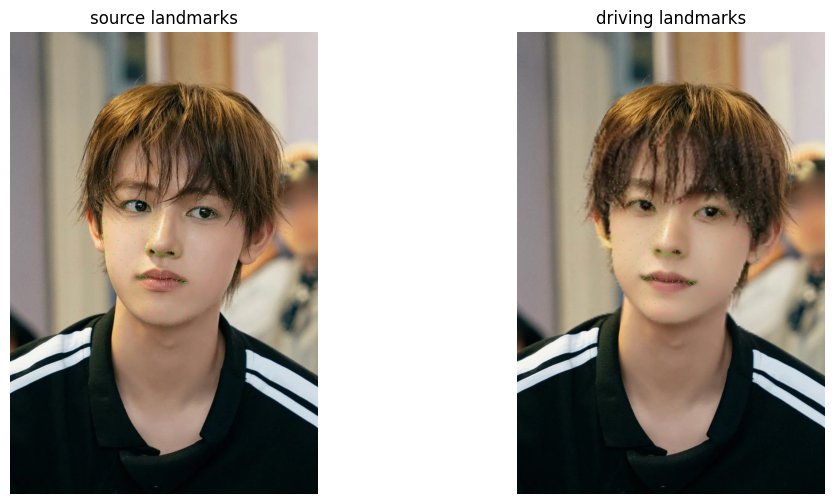

In [ ]:
def draw_pts(img_path: str, pts468: np.ndarray):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    vis = img.copy()
    for x, y, _ in pts468:
        cv2.circle(vis, (int(x * w), int(y * h)), 1, (0, 255, 0), -1)

    return vis

src_vis = draw_pts(SRC_IMG, src_pts468)
drv_vis = draw_pts(DRV_IMG, drv_pts468)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(src_vis)
plt.title("source landmarks")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(drv_vis)
plt.title("driving landmarks")
plt.axis("off")
plt.show()

In [ ]:
import os, shutil

INPUT_DIR = "/content/PIRender/custom_input"
os.makedirs(INPUT_DIR, exist_ok=True)

# source 이미지는 그대로 사용
shutil.copy(SRC_IMG, f"{INPUT_DIR}/frame_00000.jpg")

# source와 driving의 normalized landmark 차이
delta = drv_pts468 - src_pts468
delta_xy = delta[:, :2].reshape(-1)

pir_coeff = np.zeros(262, dtype=np.float32)

# expression 슬롯: landmark 변화량 일부만 사용
# 너무 크면 얼굴이 터지니까 scale 작게
exp_feat = delta_xy[:64] * 0.35
pir_coeff[80:144] = exp_feat

# pose 슬롯: transformation matrix가 있으면 아주 약하게 추출
# 없으면 0
if drv_mat is not None and src_mat is not None:
    # translation-like effect from matrix difference
    # 정확한 3DMM pose는 아니고 약한 근사치
    pose_delta = (drv_mat[:3, 3] - src_mat[:3, 3]).astype(np.float32)
    pir_coeff[224:227] = pose_delta[:3] * 0.1
else:
    pir_coeff[224:227] = np.array([0.0, 0.0, 0.0], dtype=np.float32)

# translation/crop은 일단 0으로
pir_coeff[254:257] = np.array([0.0, 0.0, 0.0], dtype=np.float32)
pir_coeff[259:262] = np.array([0.0, 0.0, 0.0], dtype=np.float32)

np.savetxt(f"{INPUT_DIR}/frame_00000_3dmm_coeff.txt", pir_coeff[None], fmt="%.8f")

print("saved image:", f"{INPUT_DIR}/frame_00000.jpg")
print("saved coeff:", f"{INPUT_DIR}/frame_00000_3dmm_coeff.txt")
print("pose slot:", pir_coeff[224:227])
print("exp slot sample:", pir_coeff[80:90])

saved image: /content/PIRender/custom_input/frame_00000.jpg
saved coeff: /content/PIRender/custom_input/frame_00000_3dmm_coeff.txt
pose slot: [-0.0039021   0.0086009   0.02480583]
exp slot sample: [-1.25698594e-03  1.73704326e-03 -1.82088616e-03 -1.97611749e-04
 -1.29416131e-03  1.79305662e-05 -1.76300551e-03  8.92251701e-05
 -1.89212861e-03 -1.15072726e-04]


In [ ]:
%cd /content/PIRender
!python run_image_inference.py

/content/PIRender
2026-03-26 07:21:21.629468: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774509681.649735    8178 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774509681.656426    8178 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774509681.673858    8178 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774509681.673883    8178 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774509681.673887    8178 computation_placer.cc:177] comp

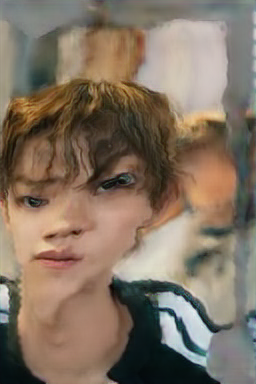

In [ ]:
from IPython.display import Image, display
display(Image(filename="/content/PIRender/custom_result/result.png"))

In [ ]:
# blendshape를 쓰는 대안
# source 대비 driving 표정 차이만 사용
pir_coeff_bs = np.zeros(262, dtype=np.float32)

if src_blend is not None and drv_blend is not None:
    keys = sorted(set(src_blend.keys()) & set(drv_blend.keys()))
    blend_delta = np.array([drv_blend[k] - src_blend[k] for k in keys], dtype=np.float32)

    n = min(64, len(blend_delta))
    pir_coeff_bs[80:80+n] = blend_delta[:n] * 0.8

np.savetxt(f"{INPUT_DIR}/frame_00000_3dmm_coeff.txt", pir_coeff_bs[None], fmt="%.8f")
print("saved blendshape-based coeff")
print("nonzero exp dims:", np.count_nonzero(pir_coeff_bs[80:144]))

saved blendshape-based coeff
nonzero exp dims: 52


In [ ]:
%cd /content/PIRender
!python run_image_inference.py

/content/PIRender
2026-03-26 07:21:40.936659: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774509700.956643    8276 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774509700.963321    8276 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774509700.979849    8276 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774509700.979874    8276 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774509700.979877    8276 computation_placer.cc:177] comp

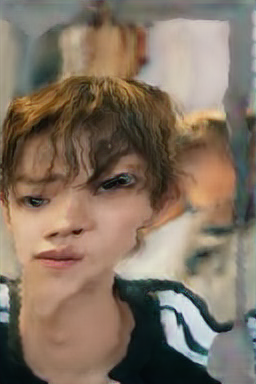

In [ ]:
from IPython.display import Image, display
display(Image(filename="/content/PIRender/custom_result/result.png"))

이건 media만

In [ ]:
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay

In [ ]:
SRC_PATH = "/content/source.jpeg"
DRV_PATH = "/content/driving1.jpeg"

src_img = cv2.imread(SRC_PATH)
drv_img = cv2.imread(DRV_PATH)

assert src_img is not None, "source.jpg 못 읽음"
assert drv_img is not None, "driving.jpg 못 읽음"

print("src:", src_img.shape)
print("drv:", drv_img.shape)

src: (1500, 1000, 3)
drv: (1000, 1000, 3)


In [ ]:
import os

MODEL_PATH = "/content/face_landmarker.task"
SRC_IMG = "/content/source.jpeg"
DRV_IMG = "/content/close.jpg"

print("model:", os.path.exists(MODEL_PATH))
print("source:", os.path.exists(SRC_IMG))
print("driving:", os.path.exists(DRV_IMG))

model: True
source: True
driving: True


In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt

BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.IMAGE,
    num_faces=1,
    min_face_detection_confidence=0.5,
    min_face_presence_confidence=0.5,
    min_tracking_confidence=0.5,
    output_face_blendshapes=True,
    output_facial_transformation_matrixes=True,
)

def detect_face_landmarks(img_path: str):
    mp_image = mp.Image.create_from_file(img_path)

    with FaceLandmarker.create_from_options(options) as landmarker:
        result = landmarker.detect(mp_image)

    if len(result.face_landmarks) == 0:
        raise ValueError(f"No face detected: {img_path}")

    # 468개 3D landmark
    lms = result.face_landmarks[0]
    pts468 = np.array([[lm.x, lm.y, lm.z] for lm in lms], dtype=np.float32)

    # blendshape
    blendshapes = None
    if result.face_blendshapes:
        blendshapes = {c.category_name: c.score for c in result.face_blendshapes[0]}

    # facial transformation matrix
    matrix = None
    if result.facial_transformation_matrixes:
        matrix = np.array(result.facial_transformation_matrixes[0], dtype=np.float32)

    return pts468, blendshapes, matrix

src_pts468, src_blend, src_mat = detect_face_landmarks(SRC_IMG)
drv_pts468, drv_blend, drv_mat = detect_face_landmarks(DRV_IMG)

print("src_pts468:", src_pts468.shape)
print("drv_pts468:", drv_pts468.shape)
print("src_mat shape:", None if src_mat is None else src_mat.shape)
print("drv_mat shape:", None if drv_mat is None else drv_mat.shape)
print("blendshape keys sample:", list(drv_blend.keys())[:10] if drv_blend else None)

src_pts468: (478, 3)
drv_pts468: (478, 3)
src_mat shape: (4, 4)
drv_mat shape: (4, 4)
blendshape keys sample: ['_neutral', 'browDownLeft', 'browDownRight', 'browInnerUp', 'browOuterUpLeft', 'browOuterUpRight', 'cheekPuff', 'cheekSquintLeft', 'cheekSquintRight', 'eyeBlinkLeft']


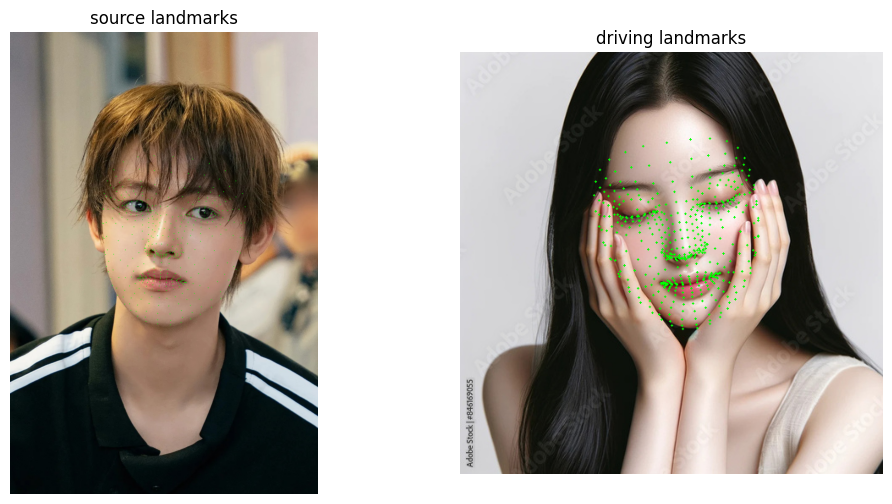

In [ ]:
def draw_pts(img_path: str, pts468: np.ndarray):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    vis = img.copy()
    for x, y, _ in pts468:
        cv2.circle(vis, (int(x * w), int(y * h)), 1, (0, 255, 0), -1)

    return vis

src_vis = draw_pts(SRC_IMG, src_pts468)
drv_vis = draw_pts(DRV_IMG, drv_pts468)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(src_vis)
plt.title("source landmarks")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(drv_vis)
plt.title("driving landmarks")
plt.axis("off")
plt.show()

In [ ]:
import json

# landmark 저장
np.save("/content/src_pts468.npy", src_pts468)
np.save("/content/drv_pts468.npy", drv_pts468)

# matrix 저장
if src_mat is not None:
    np.save("/content/src_mat.npy", src_mat)
if drv_mat is not None:
    np.save("/content/drv_mat.npy", drv_mat)

# blendshape 저장
with open("/content/src_blend.json", "w", encoding="utf-8") as f:
    json.dump(src_blend if src_blend else {}, f, ensure_ascii=False, indent=2)

with open("/content/drv_blend.json", "w", encoding="utf-8") as f:
    json.dump(drv_blend if drv_blend else {}, f, ensure_ascii=False, indent=2)

print("saved:")
print("/content/src_pts468.npy")
print("/content/drv_pts468.npy")
print("/content/src_mat.npy")
print("/content/drv_mat.npy")
print("/content/src_blend.json")
print("/content/drv_blend.json")

saved:
/content/src_pts468.npy
/content/drv_pts468.npy
/content/src_mat.npy
/content/drv_mat.npy
/content/src_blend.json
/content/drv_blend.json


In [ ]:
print("src landmark sample:\n", src_pts468[:5])
print("\ndrv landmark sample:\n", drv_pts468[:5])

if src_mat is not None:
    print("\nsrc_mat:\n", src_mat)

if drv_mat is not None:
    print("\ndrv_mat:\n", drv_mat)

if drv_blend:
    print("\ndrv_blend sample:")
    for i, (k, v) in enumerate(drv_blend.items()):
        print(k, v)
        if i >= 9:
            break

src landmark sample:
 [[ 0.4891012   0.51577014 -0.05355199]
 [ 0.49071467  0.47358596 -0.10421515]
 [ 0.49210617  0.48828724 -0.05240889]
 [ 0.48397586  0.42640072 -0.07791457]
 [ 0.49240148  0.4591569  -0.11160559]]

drv landmark sample:
 [[ 0.540749    0.5323131  -0.02969212]
 [ 0.5307048   0.48059005 -0.08534467]
 [ 0.53346354  0.49390966 -0.03826705]
 [ 0.507514    0.42726487 -0.07602052]
 [ 0.52798307  0.46516296 -0.09415418]]

src_mat:
 [[  0.9893026    0.09660017  -0.10931215   0.65803283]
 [ -0.10373403   0.9926983   -0.06156336   2.6973848 ]
 [  0.10256693   0.07224414   0.99209946 -41.427345  ]
 [  0.           0.           0.           1.        ]]

drv_mat:
 [[ 9.8536706e-01 -1.6395703e-01  4.6584874e-02  7.4667513e-01]
 [ 1.7044114e-01  9.5001864e-01 -2.6156288e-01  3.3963184e+00]
 [-1.3714102e-03  2.6567525e-01  9.6406192e-01 -3.3569569e+01]
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00  1.0000000e+00]]

drv_blend sample:
_neutral 1.4451816241489723e-06
browDownLeft 0.0

In [ ]:
# 테스트용 대표 포인트
USE_IDX = sorted(set([
    # contour / jaw
    10, 338, 297, 332, 284, 251, 389, 356, 454, 323, 361, 288, 397, 365, 379, 378, 400, 377,
    152, 148, 176, 149, 150, 136, 172, 58, 132, 93, 234, 127, 162, 21, 54, 103, 67, 109,

    # eyebrows
    70, 63, 105, 66, 107,
    336, 296, 334, 293, 300,

    # nose
    168, 6, 197, 195, 5, 4, 1, 19, 94, 2,

    # eyes
    33, 160, 158, 133, 153, 144,
    362, 385, 387, 263, 373, 380,

    # mouth
    61, 40, 37, 0, 267, 270, 291, 321, 314, 17, 84, 91,
    78, 81, 13, 311, 308, 402, 14, 178
]))

src_pts2 = src_pts468[USE_IDX, :2].copy()
drv_pts2 = drv_pts468[USE_IDX, :2].copy()

print(src_pts2.shape, drv_pts2.shape)

(88, 2) (88, 2)


In [ ]:
src_img = cv2.imread(SRC_IMG)
drv_img = cv2.imread(DRV_IMG)

def align_points_to_source(src_pts, drv_pts):
    src_center = src_pts.mean(axis=0, keepdims=True)
    drv_center = drv_pts.mean(axis=0, keepdims=True)

    src_scale = np.max(np.linalg.norm(src_pts - src_center, axis=1))
    drv_scale = np.max(np.linalg.norm(drv_pts - drv_center, axis=1))

    aligned = (drv_pts - drv_center) / (drv_scale + 1e-6) * src_scale + src_center
    return aligned

drv_pts2_aligned = align_points_to_source(src_pts2, drv_pts2)

print(drv_pts2_aligned[:5])

[[0.52661407 0.5540829 ]
 [0.5158493  0.49864915]
 [0.5188059  0.5129243 ]
 [0.5129323  0.4821153 ]
 [0.50897545 0.45774117]]


In [ ]:
def add_boundary_points(pts, img_shape):
    h, w = img_shape[:2]
    boundary = np.array([
        [0, 0], [w//2, 0], [w-1, 0],
        [w-1, h//2],
        [w-1, h-1], [w//2, h-1], [0, h-1],
        [0, h//2]
    ], dtype=np.float32)
    return np.vstack([pts, boundary])

src_pts_all = add_boundary_points(src_pts2, src_img.shape)
drv_pts_all = add_boundary_points(drv_pts2_aligned, src_img.shape)

print(src_pts_all.shape, drv_pts_all.shape)

(96, 2) (96, 2)


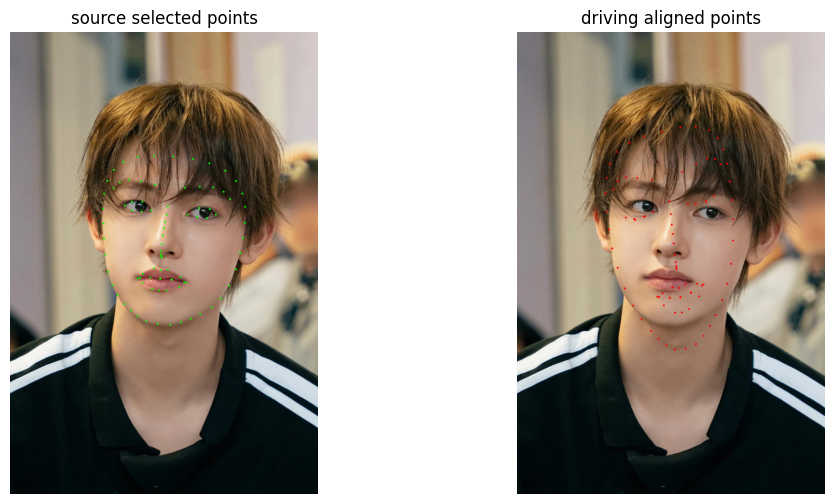

In [ ]:
def draw_selected_points(img_bgr, pts_norm, color=(0,255,0)):
    vis = cv2.cvtColor(img_bgr.copy(), cv2.COLOR_BGR2RGB)
    h, w = img_bgr.shape[:2]

    for x, y in pts_norm:
        px = int(x * w)
        py = int(y * h)
        cv2.circle(vis, (px, py), 3, color, -1)

    return vis

src_vis2 = draw_selected_points(src_img, src_pts_all[:-8])
drv_vis2 = draw_selected_points(src_img, drv_pts_all[:-8], color=(255,0,0))

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(src_vis2)
plt.title("source selected points")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(drv_vis2)
plt.title("driving aligned points")
plt.axis("off")
plt.show()

In [ ]:
def norm_to_pixel(pts_norm, img_shape):
    h, w = img_shape[:2]
    pts = pts_norm.copy().astype(np.float32)
    pts[:, 0] *= w
    pts[:, 1] *= h
    return pts

src_pts_all_px = norm_to_pixel(src_pts_all, src_img.shape)
drv_pts_all_px = norm_to_pixel(drv_pts_all, src_img.shape)

print(src_pts_all_px[:5])
print(drv_pts_all_px[:5])

[[489.1012  773.6552 ]
 [490.71466 710.37897]
 [492.10617 732.43085]
 [492.4015  688.73535]
 [496.37033 660.87415]]
[[526.6141  831.1243 ]
 [515.8493  747.97375]
 [518.8059  769.3865 ]
 [512.9323  723.173  ]
 [508.97543 686.61176]]


In [ ]:
from scipy.spatial import Delaunay

def apply_affine_transform(src, src_tri, dst_tri, size):
    warp_mat = cv2.getAffineTransform(np.float32(src_tri), np.float32(dst_tri))
    dst = cv2.warpAffine(
        src, warp_mat, (size[0], size[1]),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT_101
    )
    return dst

def warp_triangle(img_src, img_dst, t_src, t_dst):
    r1 = cv2.boundingRect(np.float32([t_src]))
    r2 = cv2.boundingRect(np.float32([t_dst]))

    t1_rect = []
    t2_rect = []
    t2_rect_int = []

    for i in range(3):
        t1_rect.append((t_src[i][0] - r1[0], t_src[i][1] - r1[1]))
        t2_rect.append((t_dst[i][0] - r2[0], t_dst[i][1] - r2[1]))
        t2_rect_int.append((int(t_dst[i][0] - r2[0]), int(t_dst[i][1] - r2[1])))

    mask = np.zeros((r2[3], r2[2], 3), dtype=np.float32)
    cv2.fillConvexPoly(mask, np.int32(t2_rect_int), (1.0, 1.0, 1.0), 16, 0)

    img1_rect = img_src[r1[1]:r1[1]+r1[3], r1[0]:r1[0]+r1[2]]
    size = (r2[2], r2[3])
    img2_rect = apply_affine_transform(img1_rect, t1_rect, t2_rect, size)
    img2_rect = img2_rect * mask

    img_dst_part = img_dst[r2[1]:r2[1]+r2[3], r2[0]:r2[0]+r2[2]]
    img_dst_part = img_dst_part * (1.0 - mask)
    img_dst_part = img_dst_part + img2_rect

    img_dst[r2[1]:r2[1]+r2[3], r2[0]:r2[0]+r2[2]] = img_dst_part

In [ ]:
tri = Delaunay(src_pts_all_px)
warped = np.zeros_like(src_img, dtype=np.float32)

for simplex in tri.simplices:
    t_src = src_pts_all_px[simplex]
    t_dst = drv_pts_all_px[simplex]
    warp_triangle(src_img.astype(np.float32), warped, t_src, t_dst)

warped = np.clip(warped, 0, 255).astype(np.uint8)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(src_img, cv2.COLOR_BGR2RGB))
plt.title("source")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(drv_img, cv2.COLOR_BGR2RGB))
plt.title("driving")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
plt.title("warped")
plt.axis("off")
plt.show()